# **LASSO regression (GM) + Portfolio**

In [3]:
import sys
import os

sys.path.append(os.path.abspath("../../Model Kernels"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TestDataFrame

from sklearn.preprocessing import StandardScaler

# ML Stuff
import cvxpy as cp
from sklearn.linear_model import Lasso


In [4]:
# Pre-processed data preparation
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TestDataFrame()

In [5]:
def markowitz(predicted_returns, lambda_risk, cov_matrix):
    '''
    Markowitz portfolio optimization implementation using cvxpy.
    predicted_returns: np.array of predicted returns for each asset
    lambda_risk: risk aversion parameter
    returns: optimal weights for each asset
    '''
    w = cp.Variable(len(predicted_returns))

    objective = cp.Maximize(predicted_returns @ w - lambda_risk * cp.quad_form(w, cov_matrix))

    constraints = [cp.sum(w) == 1, w >= 0]

    problem = cp.Problem(objective, constraints)
    problem.solve()

    return w.value

In [6]:
def markowitz_with_tc(
    predicted_returns,
    cov_matrix,
    prev_weights,
    lambda_risk=20,
    lambda_tc=0.01
):
    """
    Markowitz optimization with transaction cost / turnover penalty.
    """

    n = len(predicted_returns)
    w = cp.Variable(n)

    objective = cp.Maximize(
        predicted_returns @ w
        - lambda_risk * cp.quad_form(w, cov_matrix)
        - lambda_tc * cp.norm1(w - prev_weights)
    )

    constraints = [
        cp.sum(w) == 1,
        w >= 0
    ]

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.OSQP)

    return w.value


In [7]:
def markowitz_clean(weights, threshold=1e-6):
    '''
    Cleans the weights by setting very small weights to zero and re-normalizing.
    weights: np.array of weights
    threshold: minimum weight to keep
    returns: cleaned weights
    '''
    weights_cleaned = np.where(weights < threshold, 0, weights)
    if np.sum(weights_cleaned) > 0:
        weights_cleaned /= np.sum(weights_cleaned)
    return weights_cleaned

In [8]:
Stock_Data = pd.read_sql(f"SELECT Ticker, Date, Close FROM StockData ORDER BY Ticker", con=StockDataDatabase, parse_dates=["Date"])

prices_frame = Stock_Data.pivot(index="Date", columns="Ticker", values="Close").sort_index().ffill()
historical_returns = prices_frame.pct_change().dropna()

# **LASSO regression**

In [9]:
all_data = {}

for ticker in tickers["Ticker"]:
    # Bounded training-validation set
    df = pd.read_sql(
        f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2022-10-01'",
        con=StockDataDatabase,
        parse_dates=["Date"]
    )
    df = pd.merge(df, TrainingDataFrame, on="Date")
    df["Target"] = df["Close"]
    df = df.dropna().reset_index(drop=True)
    all_data[ticker] = df

In [10]:
training_length = 4 # This was optimized previously
prediction_length = 1

dates = all_data[tickers["Ticker"].iloc[0]]["Date"]


In [ ]:
portfolio_predictions = {}

# Calculate predictions for the next days
for t in range(len(dates) - (training_length + prediction_length)):

    current_date = dates.iloc[t + training_length]
    portfolio_predictions[current_date] = {}

    for ticker, Stock_Data in all_data.items():

        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            Stock_Data[historic_columns].iloc[t:t+training_length]
        )
        y_train = Stock_Data["Target"].iloc[t:t+training_length]

        X_test = scaler.transform(
            Stock_Data[historic_columns].iloc[t+training_length:t+training_length+prediction_length]
        )

        model = Lasso(alpha=4.15, max_iter=3000) # This was optimized previously
        model.fit(X_train, y_train)

        prediction = model.predict(X_test)[0]

        pct_return = (prediction - Stock_Data["Close"].iloc[t+training_length-1]) / Stock_Data["Close"].iloc[t+training_length-1]

        portfolio_predictions[current_date][ticker] = pct_return

        print(f"Date: {current_date.date()}, Ticker: {ticker}, Prediction: {pct_return}")


For benchmarking, we do <code>pct_change()</code> for indices as well, we will benchmark to them.

In [12]:
snp = pd.read_sql("SELECT Date, Close FROM Indexes WHERE IndexName='S&P 500'", con=StockDataDatabase, parse_dates=["Date"])

snp["Return"] = snp["Close"].pct_change()

snp = snp.dropna()

In [13]:
nasdaq = pd.read_sql("SELECT Date, Close FROM Indexes WHERE IndexName='NASDAQ'", con=StockDataDatabase, parse_dates=["Date"])

nasdaq["Return"] = nasdaq["Close"].pct_change()
nasdaq = nasdaq.dropna()

In [14]:
def simulate_portfolio(
    lambda_risk=20,
    cov_window=60,
    lambda_tc=0.01,
    reportion=False
):
    '''
    Complete portfolio simulation with Markowitz optimization and transaction costs.
    lambda_risk: risk aversion parameter
    cov_window: window size for covariance matrix estimation
    lambda_tc: transaction cost penalty parameter
    reportion: if True, prints progress reports
    returns: portfolio values, benchmark values, weights history, turnover history
    '''
    initial_capital = 100

    capital = initial_capital
    capital_benchmark1 = initial_capital
    capital_benchmark2 = initial_capital

    portfolio_values = []
    snp_values = []
    nasdaq_values = []

    weights_history = []
    turnover_history = []

    t_start = 30

    # Explicit, no trading previously
    prev_weights = np.zeros(len(historical_returns.columns))

    for t in range(t_start, len(dates) - (training_length + prediction_length)):

        current_date = dates.iloc[t + training_length]

        # Covariance estimation
        covariance_data = historical_returns.loc[:current_date].tail(cov_window)
        cov_matrix = covariance_data.cov().values
        cov_matrix += 1e-6 * np.eye(cov_matrix.shape[0])

        # Predicted returns
        predicted_returns = np.array(
            list(portfolio_predictions[current_date].values())
        )

        # Portfolio optimization with turnover penalty
        optimal_weights = markowitz_clean(
            markowitz_with_tc(
                predicted_returns,
                cov_matrix=cov_matrix,
                prev_weights=prev_weights,
                lambda_risk=lambda_risk,
                lambda_tc=lambda_tc
            )
        )

        # Realized returns, based on next day after prediction
        next_day_index = t + training_length + prediction_length
        realized_r = historical_returns.iloc[next_day_index].values

        realized_bench = snp.iloc[next_day_index]["Return"]
        realized_nasdaq = nasdaq.iloc[next_day_index]["Return"]

        # Update portfolio values
        portfolio_return = np.dot(optimal_weights, realized_r)

        capital *= (1 + portfolio_return)
        capital_benchmark1 *= (1 + realized_bench)
        capital_benchmark2 *= (1 + realized_nasdaq)

        # Well, well, well...
        turnover = np.sum(np.abs(optimal_weights - prev_weights))

        portfolio_values.append(capital)
        snp_values.append(capital_benchmark1)
        nasdaq_values.append(capital_benchmark2)

        weights_history.append(optimal_weights)
        turnover_history.append(turnover)

        prev_weights = optimal_weights.copy()

        if reportion:
            print(
                f"Date: {current_date + pd.Timedelta(days=1)}, "
                f"Capital: {capital:.2f}, "
                f"Turnover: {turnover:.2f}"
            )

    return (
        np.array(portfolio_values),
        np.array(snp_values),
        np.array(nasdaq_values),
        np.array(weights_history),
        np.array(turnover_history),
    )


# **Test evaluation**


In [15]:
conservative, snp_values, nasdaq_values, _, _  = simulate_portfolio(lambda_risk=1000, reportion=True)

Date: 2023-01-05 00:00:00, Capital: 99.55, Turnover: 1.00
Date: 2023-01-06 00:00:00, Capital: 98.77, Turnover: 0.02
Date: 2023-01-07 00:00:00, Capital: 99.00, Turnover: 0.14
Date: 2023-01-10 00:00:00, Capital: 100.63, Turnover: 0.18
Date: 2023-01-11 00:00:00, Capital: 100.88, Turnover: 0.40
Date: 2023-01-12 00:00:00, Capital: 100.87, Turnover: 0.09
Date: 2023-01-13 00:00:00, Capital: 100.87, Turnover: 0.11
Date: 2023-01-14 00:00:00, Capital: 99.04, Turnover: 0.09
Date: 2023-01-18 00:00:00, Capital: 99.13, Turnover: 0.05
Date: 2023-01-19 00:00:00, Capital: 98.25, Turnover: 0.03
Date: 2023-01-20 00:00:00, Capital: 98.18, Turnover: 0.30
Date: 2023-01-21 00:00:00, Capital: 98.55, Turnover: 0.19
Date: 2023-01-24 00:00:00, Capital: 97.72, Turnover: 0.08
Date: 2023-01-25 00:00:00, Capital: 97.34, Turnover: 0.09
Date: 2023-01-26 00:00:00, Capital: 96.90, Turnover: 0.00
Date: 2023-01-27 00:00:00, Capital: 97.07, Turnover: 0.10
Date: 2023-01-28 00:00:00, Capital: 96.29, Turnover: 0.06
Date: 2023

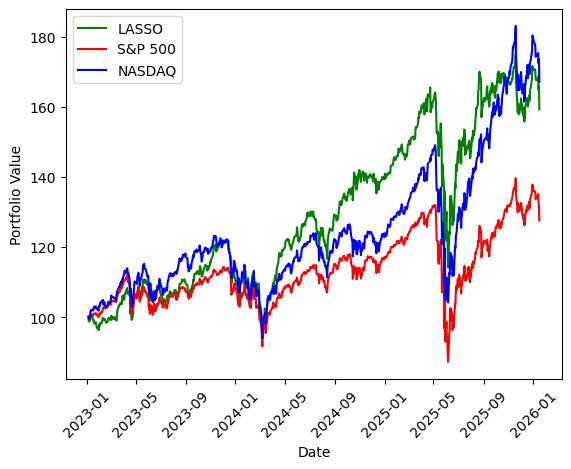

In [16]:
plt.plot(dates[35:], conservative, c="green")
plt.plot(dates[35:], snp_values, c="red")
plt.plot(dates[35:], nasdaq_values, c="blue")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend(["LASSO", "S&P 500", "NASDAQ"])

plt.xticks(rotation=45)

plt.show()

In [17]:
def cagr(portfolio_values, periods_per_year=252):
    '''
    Calculate the Compound Annual Growth Rate (CAGR) of a portfolio.
    portfolio_values: list or np.array of portfolio values over time
    periods_per_year: number of periods in a year (e.g., 252 for daily data)
    returns: CAGR value
    '''
    years = len(portfolio_values) / periods_per_year
    cagr_value = (portfolio_values[-1] / portfolio_values[0]) ** (1 / years) - 1
    return 100*cagr_value

In [18]:
def volatility(portfolio_values, periods_per_year=252):
    '''
    Calculate the annualized volatility of a portfolio.
    portfolio_values: list or np.array of portfolio values over time
    periods_per_year: number of periods in a year (e.g., 252 for daily data)
    returns: annualized volatility value
    '''
    return 100*np.std(portfolio_values[1:] / portfolio_values[:-1] - 1) * np.sqrt(periods_per_year)


In [19]:
def sharpe_ratio(portfolio_values):
    '''
    Calculate the Sharpe Ratio of a portfolio.
    portfolio_values: list or np.array of portfolio values over time
    returns: Sharpe Ratio value
    '''
    return cagr(portfolio_values) / volatility(portfolio_values)

In [20]:
print(f"CAGR: {cagr(conservative):.2f} %")
print(f"Volatility: {volatility(conservative):.2f} %")
print(f"Sharpe Ratio: {sharpe_ratio(conservative):.2f}")

CAGR: 16.88 %
Volatility: 25.53 %
Sharpe Ratio: 0.66


In [21]:
print(f"CAGR: {cagr(snp_values):.2f} %")
print(f"Volatility: {volatility(snp_values):.2f} %")
print(f"Sharpe Ratio: {sharpe_ratio(snp_values):.2f}")

CAGR: 8.35 %
Volatility: 23.10 %
Sharpe Ratio: 0.36


In [22]:
print(f"CAGR: {cagr(nasdaq_values):.2f} %")
print(f"Volatility: {volatility(nasdaq_values):.2f} %")
print(f"Sharpe Ratio: {sharpe_ratio(nasdaq_values):.2f}")

CAGR: 18.51 %
Volatility: 25.15 %
Sharpe Ratio: 0.74
